# Police Distraction Detection — T5
**Single Model**: Neural Network (PyTorch)  
**Data**: 1 lakh raw rows → 90% Neutral, 10% Distracted  
**Output**: Full scored CSV with distraction score + dynamic threshold label

In [1]:
!pip install scikit-learn pandas numpy scipy torch onnxruntime onnxscript --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 15.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt

from scipy.stats import entropy
from scipy.signal import find_peaks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

print('All imports successful.')

All imports successful.


## 1. Feature Engineering Functions

In [3]:
WINDOW = 60
STEP   = 10

def movement_entropy(signal, bins=10):
    hist, _ = np.histogram(signal, bins=bins, density=True)
    hist += 1e-8
    return entropy(hist)

def micro_motion_frequency(signal):
    peaks, _ = find_peaks(signal)
    return len(peaks)

def compute_features(window):
    acc_mag  = np.sqrt(window['accel_x']**2 + window['accel_y']**2 + window['accel_z']**2)
    gyro_mag = np.sqrt(window['gyro_x']**2  + window['gyro_y']**2  + window['gyro_z']**2)
    dist     = np.sqrt(window['lat_delta']**2 + window['lon_delta']**2)
    speed    = np.mean(dist / (window['time_delta'] + 1e-6))
    return {
        'motion_variance':  np.var(acc_mag),
        'gyro_variance':    np.var(gyro_mag),
        'movement_entropy': movement_entropy(acc_mag),
        'micro_motion':     micro_motion_frequency(acc_mag),
        'hr_variance':      np.var(window['heart_rate']),
        'hr_slope':         (window['heart_rate'].iloc[-1] - window['heart_rate'].iloc[0]) / len(window),
        'speed':            speed,
    }

def label_rule(f):
    if (f['motion_variance'] < 0.05 and f['movement_entropy'] < 1.5
            and f['micro_motion'] < 8 and f['speed'] < 0.0001):
        return 'Focused'
    elif (f['motion_variance'] > 0.15 or f['movement_entropy'] > 2.2
              or f['micro_motion'] > 20 or f['speed'] > 0.001):
        return 'Distracted'
    else:
        return 'Neutral'

def build_feature_dataset(raw_df):
    rows = []
    for start in range(0, len(raw_df) - WINDOW, STEP):
        window = raw_df.iloc[start: start + WINDOW]
        feats  = compute_features(window)
        feats['label'] = label_rule(feats)
        rows.append(feats)
    return pd.DataFrame(rows)

print('Feature functions defined.')

Feature functions defined.


## 2. Generate 1 Lakh Rows — 90% Neutral, 10% Distracted

In [4]:
# Load data: prefer local copy if available, else fall back to Kaggle path
import os
local_path = 'synthetic_police_data_100x.csv'
if os.path.exists(local_path):
    raw_df = pd.read_csv(local_path)
else:
    raw_df = pd.read_csv('/kaggle/input/datasets/akshadharodiya/ppw-dataset-100x/synthetic_police_data_100x.csv')
print(f"Raw sensor rows : {len(raw_df):,}")
print(f"Columns : {list(raw_df.columns)}")
print(raw_df.head())

Raw sensor rows : 11,942,400
Columns : ['heart_rate', 'spo2', 'skin_temperature', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'lat_delta', 'lon_delta', 'altitude', 'time_delta', 'sub_class', 'major_label']
   heart_rate       spo2  skin_temperature   accel_x   accel_y   accel_z  \
0   64.305387  97.749392         33.088643 -0.102166 -0.188964  0.000163   
1   73.246797  98.101851         33.828017 -0.026260 -0.153000  0.052159   
2   71.121307  97.587117         34.098351 -0.044850  0.042326 -0.218821   
3   72.018649  97.592167         33.664475  0.013147 -0.107633  0.052258   
4   62.061176  97.890222         34.173559 -0.064019 -0.131097 -0.186392   

     gyro_x    gyro_y    gyro_z  lat_delta  lon_delta    altitude  time_delta  \
0 -0.127603 -0.104771  0.025917   0.003767  -0.002936  221.295446   43.903539   
1  0.019749 -0.017779 -0.104965  -0.002515  -0.000893  211.794364   44.939517   
2  0.031859  0.032238 -0.075106   0.003474  -0.002102  216.460235   42.6499

In [5]:
print('Building feature dataset (sliding window)... may take some time')
feature_df = build_feature_dataset(raw_df)
print('\nFeature-dataset shape :', feature_df.shape)
print('Sample of computed features:')
print(feature_df.head())

Building feature dataset (sliding window)... may take some time

Feature-dataset shape : (1194234, 8)
Sample of computed features:
   motion_variance  gyro_variance  movement_entropy  micro_motion  \
0         0.465520       0.175647          1.249551            21   
1         0.320562       0.137506          1.375180            19   
2         0.205715       0.106279          1.387468            19   
3         0.360808       0.131058          1.427624            19   
4         0.342680       0.101793          1.390167            17   

   hr_variance  hr_slope     speed       label  
0   696.129499 -0.125378  0.000191  Distracted  
1   656.748741 -0.136782  0.000186  Distracted  
2   583.429196  0.088163  0.000189  Distracted  
3   712.348323 -1.432102  0.000181  Distracted  
4   638.646026  0.444713  0.000174  Distracted  


In [6]:
# === Compute a robust distraction score (handles desk vs moving contexts) ===
# Normalize features to 0-1 across the dataset (robust min-max)
eps = 1e-8
norm_df = feature_df.copy()
for c in ['motion_variance','gyro_variance','movement_entropy','micro_motion','hr_variance','hr_slope','speed']:
    lo = np.percentile(norm_df[c], 1)
    hi = np.percentile(norm_df[c], 99)
    norm_df[c + '_n'] = (norm_df[c] - lo) / (hi - lo + eps)
    norm_df[c + '_n'] = norm_df[c + '_n'].clip(0, 1)

# Determine moving vs desk windows using speed relative to median
median_speed = norm_df['speed'].median()
moving_mask = norm_df['speed'] > median_speed

# Weights tuned to emphasize HR features when motion is ambiguous; different for moving/desk
weights_moving = {
    'motion_variance_n': 0.10, 'gyro_variance_n': 0.10, 'movement_entropy_n': 0.15,
    'micro_motion_n': 0.20, 'hr_variance_n': 0.25, 'hr_slope_n': 0.10, 'speed_n': 0.10
}
weights_desk = {
    'motion_variance_n': 0.25, 'gyro_variance_n': 0.15, 'movement_entropy_n': 0.20,
    'micro_motion_n': 0.15, 'hr_variance_n': 0.20, 'hr_slope_n': 0.04, 'speed_n': 0.01
}

# Compute weighted score per-row depending on moving/desk
score = np.zeros(len(norm_df), dtype=float)
for i in range(len(norm_df)):
    row = norm_df.iloc[i]
    w = weights_moving if row['speed'] > median_speed else weights_desk
    s = 0.0
    for col in ['motion_variance','gyro_variance','movement_entropy','micro_motion','hr_variance','hr_slope','speed']:
        s += w[col + '_n'] * row[col + '_n']
    score[i] = s

# Normalize final score to 0-1
score = (score - score.min()) / (score.max() - score.min() + eps)
feature_df['distraction_score'] = score

# Assign labels by percentile: top 10% → Distracted, bottom 20% → Focused, rest → Neutral
p10 = np.percentile(score, 90)
p20 = np.percentile(score, 20)
def score_to_label(s):
    if s >= p10:
        return 'Distracted'
    elif s <= p20:
        return 'Focused'
    else:
        return 'Neutral'
feature_df['label'] = [score_to_label(s) for s in feature_df['distraction_score']]

print('Label distribution (by score percentiles):')
print(feature_df['label'].value_counts(normalize=True).mul(100).round(2))

# Sample up to 100k rows for training (preserve distribution)
sample_n = min(100000, len(feature_df))
sample_df = feature_df.sample(n=sample_n, random_state=42)
print(f'Sampled {len(sample_df):,} rows for training (random subsample).')

Label distribution (by score percentiles):
label
Neutral       70.0
Focused       20.0
Distracted    10.0
Name: proportion, dtype: float64
Sampled 100,000 rows for training (random subsample).


## 3. Prepare Data — Train on Full Dataset

In [7]:
FEATURE_COLS = ['motion_variance', 'gyro_variance', 'movement_entropy',
                'micro_motion', 'hr_variance', 'hr_slope', 'speed']

# Full dataset for final scoring
X_all_raw = feature_df[FEATURE_COLS].values
y_all_raw = feature_df['label'].values

# Use sampled subset (sample_df) for training if available; otherwise use full
sample_df_used = sample_df if 'sample_df' in globals() else feature_df
X_sample_raw = sample_df_used[FEATURE_COLS].values
y_sample_raw = sample_df_used['label'].values

# Binary target for NN: Distracted = 1, else 0
y_sample_bin = (y_sample_raw == 'Distracted').astype(int)
y_all_bin    = (y_all_raw == 'Distracted').astype(int)

print('Sampled training rows :', X_sample_raw.shape[0])
print('Distracted % in sample :', (y_sample_bin.mean()*100).round(2))

# 90% train / 10% test (on the sampled subset)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_sample_raw, y_sample_bin, test_size=0.10, random_state=42, stratify=y_sample_bin
)

# Scale — fit only on train, apply to both and to full dataset for scoring
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
X_all   = scaler.transform(X_all_raw)   # for scoring the full dataset

print(f'\nTrain : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}')
print(f'Full  : {X_all.shape[0]:,}')

Sampled training rows : 100000
Distracted % in sample : 9.91

Train : 90,000  |  Test : 10,000
Full  : 1,194,234


## 4. Neural Network — Train

In [8]:
class DistractionNet(nn.Module):
    def __init__(self, in_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


def train_neural_network(X_tr, y_tr, epochs=40, batch_size=1024, lr=1e-3):
    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.float32)

    # Upweight minority Distracted class by inverse frequency (y==1 means Distracted)
    n_distracted = (y_t == 1).sum().item()
    n_non = (y_t == 0).sum().item()
    pos_weight = float(n_non) / (n_distracted + 1e-8)
    sample_weights = torch.where(y_t == 1, torch.tensor(pos_weight), torch.tensor(1.0))

    dataset   = TensorDataset(X_t, y_t, sample_weights)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model     = DistractionNet(in_dim=X_tr.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb, wb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = nn.functional.binary_cross_entropy(pred, yb, weight=wb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  loss = {total_loss/len(loader):.5f}')
    return model


print('Training Neural Network...')
print(f'  Rows: {X_train.shape[0]:,}  |  Distracted in train: {(y_train==1).sum():,} of {len(y_train):,}')
nn_model = train_neural_network(X_train, y_train)
print('Training complete.')

Training Neural Network...
  Rows: 90,000  |  Distracted in train: 8,919 of 90,000
  Epoch  10/40  loss = 0.12614
  Epoch  20/40  loss = 0.08668
  Epoch  30/40  loss = 0.07865
  Epoch  40/40  loss = 0.07824
Training complete.


## 5. Distraction Score + Dynamic Threshold

In [9]:
nn_model.eval()
with torch.no_grad():
    # Model predicts P(Distracted) directly (higher = more distracted)
    nn_scores_all   = nn_model(torch.tensor(X_all,   dtype=torch.float32)).numpy()
    nn_scores_train = nn_model(torch.tensor(X_train, dtype=torch.float32)).numpy()
    nn_scores_test  = nn_model(torch.tensor(X_test,  dtype=torch.float32)).numpy()

# Use a fixed midpoint threshold for NN predictions (0.5)
TH = 0.5
print(f'NN score stats on train: mean={nn_scores_train.mean():.4f} std={nn_scores_train.std():.4f}')
print(f'Flagged as Distracted on test (>=0.5): {(nn_scores_test >= TH).mean()*100:.1f}%')

NN score stats on train: mean=0.1175 std=0.3065
Flagged as Distracted on test (>=0.5): 11.9%


## 6. Evaluation on Test Set

  CLASSIFICATION REPORT — NN (Distracted vs Not)
               precision    recall  f1-score   support

NotDistracted       1.00      0.98      0.99      9009
   Distracted       0.83      1.00      0.91       991

     accuracy                           0.98     10000
    macro avg       0.92      0.99      0.95     10000
 weighted avg       0.98      0.98      0.98     10000



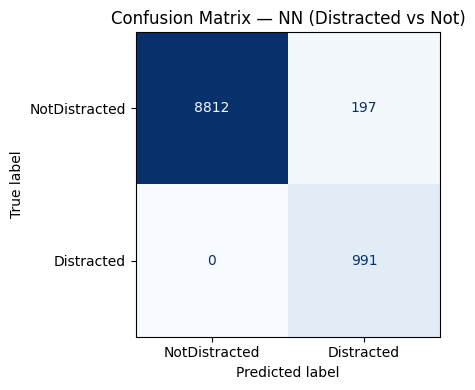

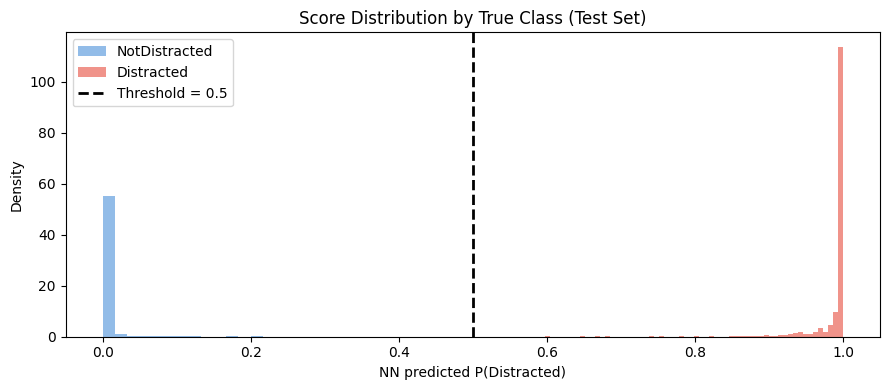

In [10]:
# Evaluate binary distracted prediction (1 = Distracted)
y_pred_mapped = (nn_scores_test >= 0.5).astype(int)

print('=' * 60)
print('  CLASSIFICATION REPORT — NN (Distracted vs Not)')
print('=' * 60)
print(classification_report(y_test, y_pred_mapped, target_names=['NotDistracted','Distracted']))

# Confusion matrix
cm   = confusion_matrix(y_test, y_pred_mapped)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NotDistracted','Distracted'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — NN (Distracted vs Not)')
plt.tight_layout()
plt.show()

# Score distribution by true label
fig, ax = plt.subplots(figsize=(9, 4))
mask_not = y_test == 0
mask_yes = y_test == 1
ax.hist(nn_scores_test[mask_not], bins=60, alpha=0.6, label='NotDistracted', color='#4A90D9', density=True)
ax.hist(nn_scores_test[mask_yes],  bins=60, alpha=0.6, label='Distracted',    color='#E74C3C', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
ax.set_xlabel('NN predicted P(Distracted)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Class (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Save Full Dataset CSV

In [11]:
output_df = feature_df[FEATURE_COLS].copy()
output_df['true_label']             = feature_df['label'].values
output_df['distraction_score_formula'] = feature_df['distraction_score'].values
output_df['nn_pred_score']          = np.round(nn_scores_all, 6)
output_df['predicted_label_nn']     = np.where(output_df['nn_pred_score'] >= 0.5, 'Distracted', 'Neutral')
output_df['threshold_used']         = 0.5

total  = len(output_df)
n_dist = (output_df['predicted_label_nn'] == 'Distracted').sum()

print(f'Total rows          : {total:,}')
print(f'Predicted Distracted (NN): {n_dist:,}  ({n_dist/total*100:.1f}%)')
print('Label distribution (from formula percentiles):')
print(output_df['true_label'].value_counts(normalize=True).mul(100).round(2))

output_df.to_csv('police_distraction_full_scored.csv', index=False)
print('\nSaved → police_distraction_full_scored.csv')
print('Columns:', list(output_df.columns))

Total rows          : 1,194,234
Predicted Distracted (NN): 139,614  (11.7%)
Label distribution (from formula percentiles):
true_label
Neutral       70.0
Focused       20.0
Distracted    10.0
Name: proportion, dtype: float64

Saved → police_distraction_full_scored.csv
Columns: ['motion_variance', 'gyro_variance', 'movement_entropy', 'micro_motion', 'hr_variance', 'hr_slope', 'speed', 'true_label', 'distraction_score_formula', 'nn_pred_score', 'predicted_label_nn', 'threshold_used']


In [12]:
print('Sample Distracted rows (by formula label):')
print(output_df[output_df['true_label'] == 'Distracted']
      [['distraction_score_formula', 'true_label', 'nn_pred_score',
        'motion_variance', 'speed', 'hr_variance']].head(10).to_string(index=False))

print('\nSample Neutral rows (by formula label):')
print(output_df[output_df['true_label'] == 'Neutral']
      [['distraction_score_formula', 'true_label', 'nn_pred_score',
        'motion_variance', 'speed', 'hr_variance']].head(10).to_string(index=False))

Sample Distracted rows (by formula label):
 distraction_score_formula true_label  nn_pred_score  motion_variance    speed  hr_variance
                  0.663490 Distracted       0.989359         0.465520 0.000191   696.129499
                  0.677735 Distracted       0.709416         0.607925 0.000188   830.129383
                  0.685333 Distracted       0.998837         0.659967 0.000220   828.554988
                  0.715739 Distracted       0.999985         0.673092 0.000233   723.140403
                  0.678662 Distracted       0.998897         0.515352 0.000230   640.589237
                  0.775001 Distracted       1.000000         0.649425 0.000262   794.963983
                  0.717515 Distracted       0.999988         0.616714 0.000246   792.932290
                  0.656678 Distracted       0.985684         0.346274 0.000238   698.488204
                  0.651185 Distracted       0.962508         0.279211 0.000212   575.519653
                  0.653487 Distracted

In [13]:
# ── Export Neural Network to ONNX ────────────────────────────────────────────
import torch
import os

nn_model.eval()

# Dummy input matching your 7 features
dummy_input = torch.randn(1, len(FEATURE_COLS), dtype=torch.float32)

onnx_path = "distraction_model.onnx"

torch.onnx.export(
    nn_model,
    dummy_input,
    onnx_path,
    dynamo=False,          # ← forces the old TorchScript exporter, no onnxscript needed
    input_names=["features"],
    output_names=["distraction_score"],
    dynamic_axes={
        "features":          {0: "batch_size"},
        "distraction_score": {0: "batch_size"},
    },
    opset_version=17,
)

print(f"ONNX model saved → {onnx_path}")
print(f"File size: {os.path.getsize(onnx_path) / 1024:.1f} KB")

# ── Quick sanity check ────────────────────────────────────────────────────────
import onnxruntime as rt

sess       = rt.InferenceSession(onnx_path)
input_name = sess.get_inputs()[0].name
sample     = X_test[:5].astype(np.float32)

ort_scores = sess.run(None, {input_name: sample})[0].flatten()
pt_scores  = nn_scores_test[:5]

print("\nONNX scores (first 5)  :", np.round(ort_scores, 4))
print("PyTorch scores (first 5):", np.round(pt_scores,  4))
print("Match:", np.allclose(ort_scores, pt_scores, atol=1e-5))

# Save label map alongside the model (binary mapping)
import json
label_map = {0: 'NotDistracted', 1: 'Distracted'}
with open("label_map.json", "w") as f:
    json.dump({"label_map": label_map, "threshold": 0.5}, f)
print("Label map + threshold saved → label_map.json:", label_map)

ONNX model saved → distraction_model.onnx
File size: 13.5 KB

ONNX scores (first 5)  : [2.000e-04 3.000e-04 6.000e-04 9.859e-01 5.000e-04]
PyTorch scores (first 5): [2.000e-04 3.000e-04 6.000e-04 9.859e-01 5.000e-04]
Match: True
Label map + threshold saved → label_map.json: {0: 'NotDistracted', 1: 'Distracted'}
